In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
filepath = r"C:\Users\chile\OneDrive\Desktop\MIT Lecture Notes\PYTHON DATA\Courseradata\eda_outliers_dataset1.csv"

In [6]:
df= pd.read_csv(filepath)
df.head(10)

,year,number_of_strikes
0,2020,15620068
1,2019,209166
2,2018,44600989
3,2017,35095195
4,2016,41582229
5,2015,37894191
6,2014,34919173
7,2013,27600898
8,2012,28807552
9,2011,31392058


Next, let's convert the number of strikes value to a more readable format on the graph
(e.g., converting 100,000 to 100K, 3,000,000 to 3M, and so on).

In [7]:
def readable_numbers(x):
    """takes a large number and formats it into K,M to make it more readable"""
    if x>= 1e6:
        s= '{:1.1f}M'.format(x*1e-6)  # format any number above six digits to be to 1 decimal place(1.1followed by an m)
    else:
        s= '{:1.0f}K'.format(x*1e-3) # format any number beyong 3 digits to 1 decimal place,
    return s
#use the readable_numbers() function to create a new column
df['numbers_of_strikes_readable']=df['number_of_strikes'].apply(readable_numbers)


In [8]:
df.head(10)

,year,number_of_strikes,numbers_of_strikes_readable
0,2020,15620068,15.6M
1,2019,209166,209K
2,2018,44600989,44.6M
3,2017,35095195,35.1M
4,2016,41582229,41.6M
5,2015,37894191,37.9M
6,2014,34919173,34.9M
7,2013,27600898,27.6M
8,2012,28807552,28.8M
9,2011,31392058,31.4M


In [9]:
# one way of finding outliers is finding the mean
print("Mean:"+ readable_numbers(np.mean(df['number_of_strikes'])))
print("Median:"+ readable_numbers(np.median(df['number_of_strikes'])))

Mean:26.8M
Median:28.3M


with mean been 2 million strikes less than median, we suspect data distribution might be skewwed to the left

A boxplot can help to visually break down the data into percentiles / quartiles, which are important summary statistics. The shaded center of the box represents the middle 50th percentile of the data points. This is the interquartile range, or IQR.

The boxplot "whiskers" extend 1.5x the IQR by defau

C:\Users\chile\AppData\Local\Temp\ipykernel_7824\1978680907.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  box.set_xticklabels(np.array([readable_numbers(x) for x in g.get_xticks()]))


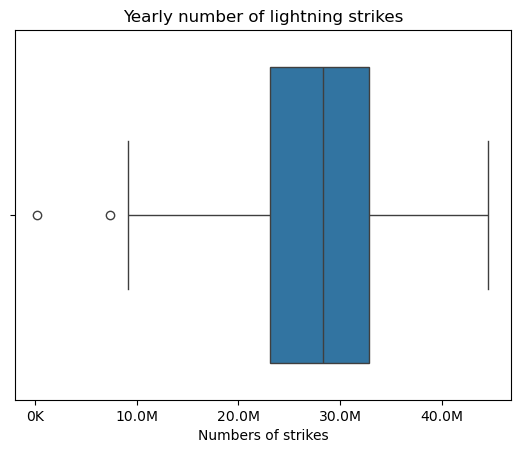

In [12]:
box= sns.boxplot(x=df['number_of_strikes'])
g= plt.gca()
box.set_xticklabels(np.array([readable_numbers(x) for x in g.get_xticks()]))
plt.xlabel('Numbers of strikes')
plt.title('Yearly number of lightning strikes');

Due to that error we improve our code using ticks
any data point that falls beyong 1.5ties the IQR is an Outlier

Text(0.5, 1.0, 'Yearly number of lightning strikes')

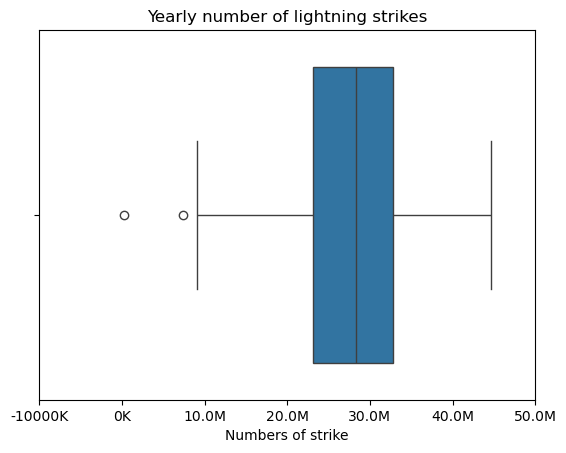

In [14]:
box= sns.boxplot(x= df['number_of_strikes'])
g= plt.gca()
ticks = g.get_xticks()
box.set_xticks(ticks)
box.set_xticklabels([readable_numbers(x) for x in ticks])
plt.xlabel('Numbers of strike')
plt.title('Yearly number of lightning strikes')

In [20]:
#calculate 25th percentile of annual strike
percentile25= df['number_of_strikes'].quantile(0.25)

#Calculate 75th %
percentile75= df['number_of_strikes'].quantile(0.75)

#calculate interquartile range
iqr= percentile75-percentile25

#calculate upper and lower thresholds for outliers
upper_limit= percentile75+ 1.5*iqr
lower_limit= percentile25 - 1.5*iqr

print('Lower limits is: '+ readable_numbers(lower_limit))

Lower limits is: 8.6M


plot value that lie below lower_limit
Now we can use a Boolean mask to select only the rows of the dataframe where the number of strikes is less than 
the lower limit we calculated above. These rows are the outliers on the low end.

In [24]:
#Isolate outliers on low end
low_outliers= df[df['number_of_strikes']< lower_limit]
high_outliers=df[df['number_of_strikes']> upper_limit]


In [25]:
low_outliers

,year,number_of_strikes,numbers_of_strikes_readable
1,2019,209166,209K
33,1987,7378836,7.4M


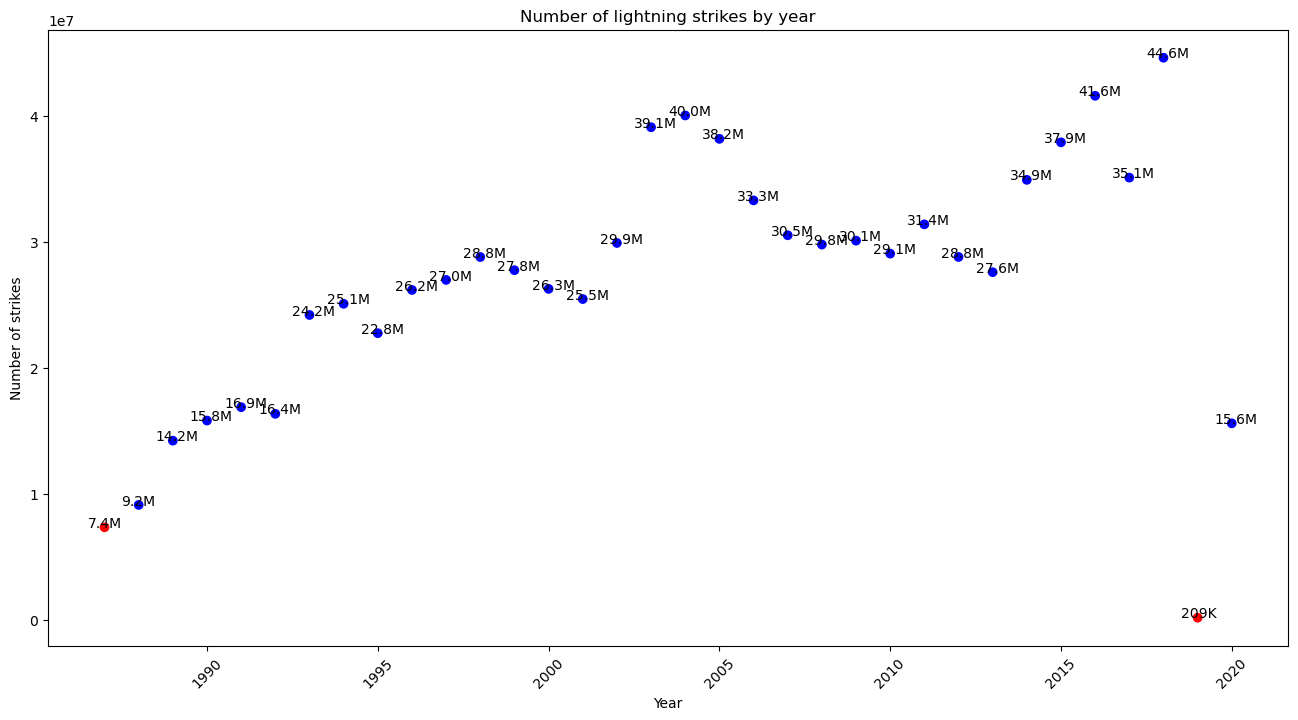

In [27]:
def addlabels(x,y):
    for i in range(len(x)):
        plt.text(x[i]-0.5, y[i]+0.05, s=readable_numbers(y[i]))

colors = np.where(df['number_of_strikes'] < lower_limit, 'r', 'b')

fig, ax = plt.subplots(figsize=(16,8))
ax.scatter(df['year'], df['number_of_strikes'],c=colors)
ax.set_xlabel('Year')
ax.set_ylabel('Number of strikes')
ax.set_title('Number of lightning strikes by year')
addlabels(df['year'], df['number_of_strikes'])
for tick in ax.get_xticklabels():
    tick.set_rotation(45)

plt.show()

# Investigating the ourlier 2019 and 1987
Lets examine the two outlier years a bit more closely. In the section above, we used a preprocessed dataset that
didnt include a lot of the information that were accustomed to having in this data. In order to further investigate the outlier years, 
well need more information, so were going to import data from these years specifically.

In [29]:
#import data dir 2019
filepath = r"C:\Users\chile\OneDrive\Desktop\MIT Lecture Notes\PYTHON DATA\Courseradata\eda_outliers_dataset2.csv"
df_2019= pd.read_csv(filepath)
df_2019.head()

,date,number_of_strikes,center_point_geom
0,2019-12-01,1,POINT(-79.7 35.3)
1,2019-12-01,1,POINT(-84.7 39.3)
2,2019-12-01,1,POINT(-83.4 38.9)
3,2019-12-01,1,POINT(-71.5 35.2)
4,2019-12-01,1,POINT(-87.8 41.6)


First, we'll convert the date column to datetime. This will enable us to extract two new columns: month and month_txt. Then, we'll sort the data by month and month_txt, sum it, and sort the values.

In [33]:
df_2019['date']= pd.to_datetime(df_2019['date'])
#create 2 new columns

df_2019['month']=df_2019['date'].dt.month
df_2019['month_txt']= df_2019['date'].dt.month_name().str.slice(stop=3)

#Group by month and month_txt sum it and sort it assign result to new df
df_2019_by_month= df_2019.groupby(['month', 'month_txt'], as_index= False).sum(numeric_only= True).sort_values('month', ascending= True).head(12)
df_2019_by_month



,month,month_txt,number_of_strikes
0,12,Dec,209166


2019 appears to have data only for the month of December. The likelihood of there not being any lightning from January to November 2019 is ~0. This appears to be a case of missing data. We should probably exclude 2019 from the analysis (for most use cases).

#Import Data for 1987
Now lets inspect the data from the other outlier year, 1987

In [34]:
filepath = r"C:\Users\chile\OneDrive\Desktop\MIT Lecture Notes\PYTHON DATA\Courseradata\eda_outliers_dataset3.csv"
df_1987= pd.read_csv(filepath)
df_1987.head()

,date,number_of_strikes,center_point_geom
0,1987-01-01,21,POINT(-80.7 26)
1,1987-01-04,23,POINT(-83.2 28.3)
2,1987-01-05,40,POINT(-78.9 31.3)
3,1987-01-05,20,POINT(-79.2 31.4)
4,1987-01-05,21,POINT(-80.1 31.4)


In [37]:
# Convert `date` column to datetime
df_1987['date'] = pd.to_datetime(df_1987['date'])

# Create 2 new columns
df_1987['month'] = df_1987['date'].dt.month
df_1987['month_txt'] = df_1987['date'].dt.month_name().str.slice(stop=3)

# Group by `month` and `month_txt`, sum it, and sort. Assign result to new df
df_1987_by_month = df_1987.groupby(['month','month_txt'],as_index= False).sum(numeric_only= True).sort_values('month', ascending=True).head(12).reset_index()
df_1987_by_month

,index,month,month_txt,number_of_strikes
0,0,1,Jan,23044
1,1,2,Feb,61020
2,2,3,Mar,117877
3,3,4,Apr,157890
4,4,5,May,700910
5,5,6,Jun,1064166
6,6,7,Jul,2077619
7,7,8,Aug,2001899
8,8,9,Sep,869833
9,9,10,Oct,105627


987 has data for every month of the year. Hence, this outlier should be treated differently than 2019, which is missing data.

Finally, let's re-run the mean and median after removing the outliers. Our final takeaway from our lesson on outliers is that outliers significantly affect the dataset's mean, but do not significantly affect the median.

To remove the outliers, we'll use a Boolean mask to create a new dataframe that contains only the rows in the original dataframe where the number of strikes >= the lower limit we calculated above.

In [40]:
#create new df that removes outliers
df_without_outliers= df[df['number_of_strikes']>= lower_limit]

#recalculate mean medua on data without outliers
print("Mean:" + readable_numbers(np.mean(df_without_outliers['number_of_strikes'])))
print("Median:" + readable_numbers(np.median(df_without_outliers['number_of_strikes']))) 



Mean:28.2M
Median:28.8M


Both the mean and the median changed, but the mean much more so. It is clear that outlier values can affect the distributions of the data and the conclusions that can be drawn from them.

If you have successfully completed the material above, congratulations! You now understand discovering in Python and should be able to start using it on your own datasets.

# Calculate median of all NON-OUTLIER values
median = np.median(df['number_of_strikes'][df['number_of_strikes'] >= lower_limit])

# Impute the median for all values < lower_limit
df['number_of_strikes'] = np.where(df['number_of_strikes'] < lower_limit, median, df['number_of_strikes'])

In [4]:
print('Hellow world')

Hellow world
